## Abstract

This study investigates the relationship between the built environment and obesity prevalence by analyzing data from the CDC PLACES dataset and the EPA Smart Location Database. Using county level data, I evaluated the predictive power of the National Walkability Index and its underlying components such as land use mix, street connectivity, and transit access on adult obesity rates. I compared a baseline Multiple Linear Regression model ($R^2 \approx 0.26$) with a Gradient Boosting Regressor, which demonstrated significantly higher predictive accuracy ($R^2 \approx 0.78$) and lower error (RMSE $\approx 1.99$). The results highlight the strong, non-linear influence of specific walkability features, particularly transit access and employment diversity, suggesting that targeted urban design interventions can serve as vital tools in public health strategies for obesity prevention.

# Summary of Process

## Overview and Motivation

The built environment plays a critical role in shaping health behaviors and outcomes. Counties with higher walkability characterized by factors such as mixed land use, residential density, and street connectivity are more likely to encourage walking, biking, and reduce reliance on automobiles. Increased opportunities for physical activity may lower the risk of obesity and other health related diseases.



## Data

Dataset(s): https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/swc5-untb/about_data The (PLACES: Local Data for Better Health, County Data 2024 release) dataset spans from 2021-2022 covering all 50 states with over 200k rows of data. The dataset uses data from the CDC to identify health problems within certain areas to create targeted plans for prevention.

Coverage: All 50 states, over 200,000 rows (county- and place-level). Time frame: Estimates derived from 2021–2022 data. Variables include: Chronic conditions: Obesity prevalence, diabetes, arthritis, COPD, heart disease. Health behaviors: Physical inactivity, smoking, binge drinking. Preventive measures: Mammography use, checkups, flu vaccination. Demographic/geographic identifiers: County FIPS code, state, location name.

https://catalog.data.gov/dataset/walkability-index8 https://www.epa.gov/smartgrowth/smart-location-mapping The Walkability Index dataset was created by the U.S. Environmental Protection Agency to summarize and inform studies on travel demands and transportation. The dataset uses data from the 2019 US census covering all states and multiple cities within them.

Coverage: U.S. nationwide, by census tract (covering urban and rural areas). Time frame: Based on 2019 U.S. Census data. Variables include: Overall walkability index score (higher = more walkable). Land use mix: Diversity of residential, commercial, institutional, and recreational areas. Employment & household mix: Balance of jobs and housing density. Street intersection density: Proxy for connectivity and ease of walking. Population & employment density.

For the PLACES dataset TotalPopulation column was converted to a numeric data type after removing the comma from the value, and the dataset was filtered on the MeasureID to keep only the statistics on Obesity. The process of joining the two datasets involved merging them on a custom created LocationID key, which was created by combining state and county codes from the EPA data, to match the LocationID from the PLACES dataset. Then the LocationIDs were grouped together in the EPA dataset to represent the entire county rather than individual blocks. After the EPA dataset was grouped it was joined with the PLACES dataset using an inner join on the LocationID column keeping only the rows with a LocationID in both datasets.

In [ ]:
import pandas as pd

#Load the CSV file into a pandas DataFrame
epa_df = pd.read_csv('/content/drive/MyDrive/Data/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv')

# Display the first few rows of the DataFrame
display(epa_df.head())

,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,...,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.184697,0.000476,0.137707,6,14,15,17,14.000000,3110.360820,297836.0831
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.323221,0.000801,0.231868,3,10,12,14,10.833333,3519.469110,484945.1466
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.314628,0.000736,0.213146,1,1,7,17,8.333333,1697.091802,106705.9281
3,4,4.811300e+11,4.811300e+11,48,113,7824,1,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.229821,0.000708,0.205018,16,10,17,17,15.666667,2922.609204,481828.4303
4,5,4.811300e+11,4.811300e+11,48,113,7824,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.164863,0.000433,0.125296,4,7,11,14,10.166667,3731.971773,687684.7752


In [ ]:
#gives the basics information about our dataset like dimension, No. of nulls , datatype of the columns
epa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Columns: 117 entries, OBJECTID to Shape_Area
dtypes: float64(73), int64(42), object(2)
memory usage: 197.0+ MB


In [ ]:
#display the different statistics of each of the columns include min, max, mean, and std
columns = epa_df[['D2A_Ranked', 'D2B_Ranked', 'D3B_Ranked', 'D4A_Ranked', 'NatWalkInd']]

display(columns.describe().T)

,count,mean,std,min,25%,50%,75%,max
D2A_Ranked,220740.0,10.500000,5.766294,1.0,5.750000,10.500000,15.250000,20.0
D2B_Ranked,220740.0,10.500000,5.766294,1.0,5.750000,10.500000,15.250000,20.0
D3B_Ranked,220740.0,10.500000,5.766294,1.0,5.750000,10.500000,15.250000,20.0
D4A_Ranked,220740.0,7.624884,7.812853,1.0,1.000000,1.000000,16.000000,20.0
NatWalkInd,220740.0,9.541628,4.373952,1.0,5.833333,9.166667,13.166667,20.0


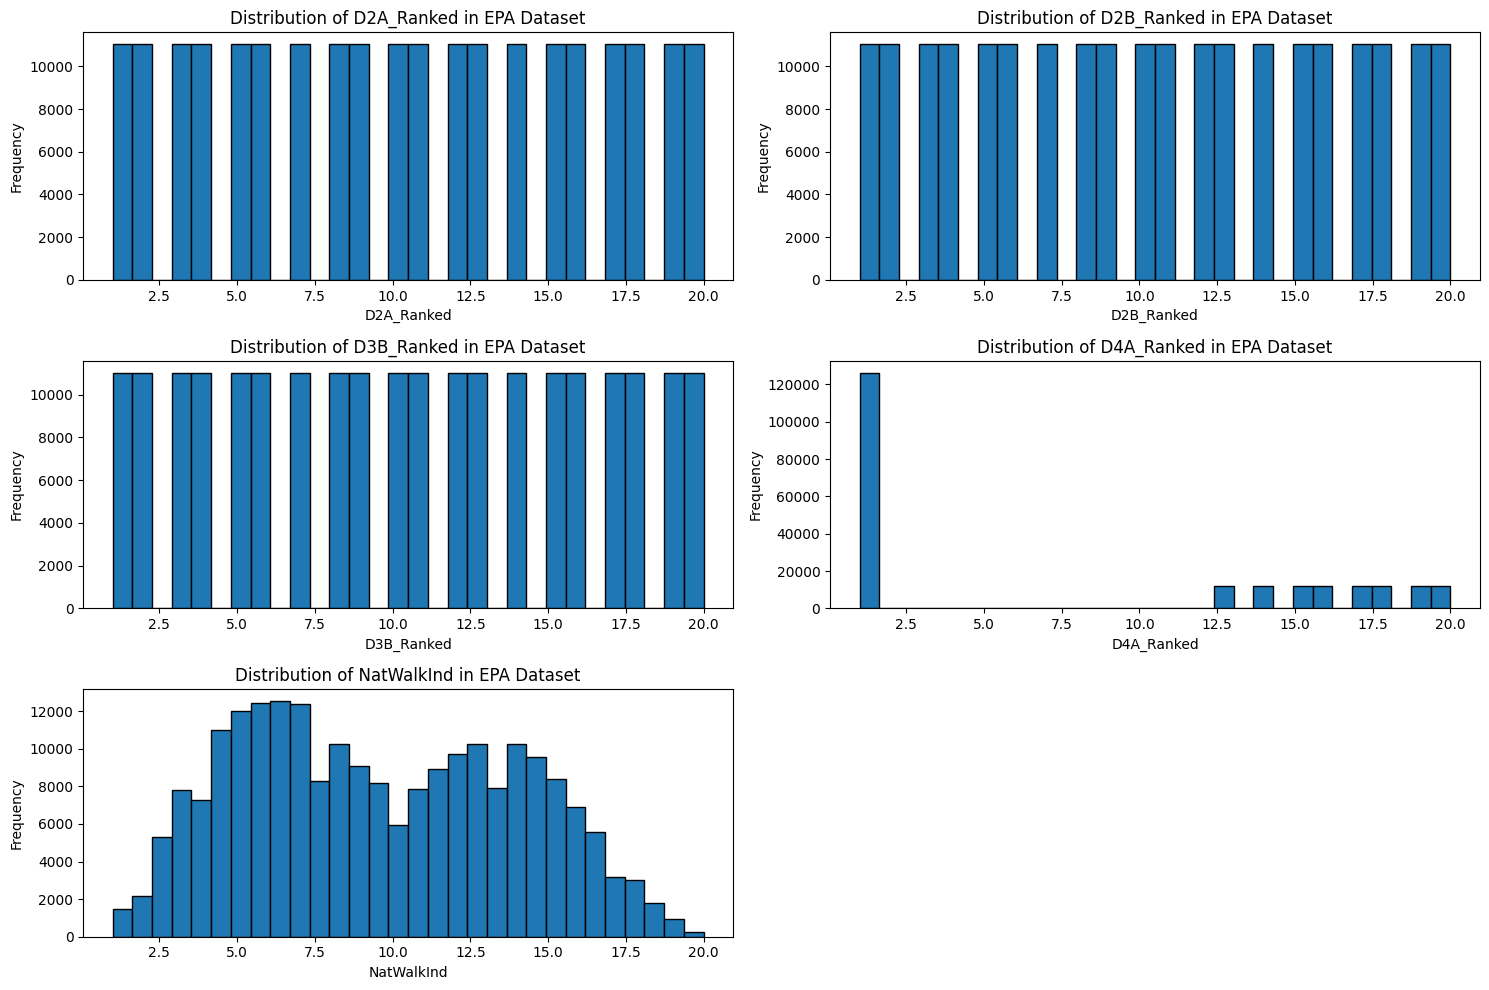

In [ ]:
import matplotlib.pyplot as plt

cols_to_plot = ['D2A_Ranked', 'D2B_Ranked', 'D3B_Ranked', 'D4A_Ranked', 'NatWalkInd']
# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

# Create histograms for each column
for i, col in enumerate(cols_to_plot):
    axes[i].hist(epa_df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col} in EPA Dataset')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Load the PLACES CSV file into a pandas DataFrame
places_df = pd.read_csv('/content/drive/MyDrive/Data/PLACES__Local_Data_for_Better_Health,_County_Data_2024_release_20250903.csv')

# Display the first few rows of the DataFrame
display(places_df.head())

/tmp/ipython-input-2121405659.py:2: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  places_df = pd.read_csv('/content/drive/MyDrive/Data/PLACES__Local_Data_for_Better_Health,_County_Data_2024_release_20250903.csv')


,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2022,AL,Alabama,Clay,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,11.0,...,9.6,12.4,"14,198","11,235",1027,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-85.8606604130173 33.2693085517833)
1,2022,AL,Alabama,Dale,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,35.6,...,34.8,36.4,"49,544","38,039",1045,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-85.6109266826185 31.4316629601359)
2,2022,AL,Alabama,Jackson,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.1,...,4.6,5.6,"52,891","42,087",1071,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-85.9995052603961 34.7796392771775)
3,2022,AL,Alabama,Lauderdale,BRFSS,Health Outcomes,Obesity among adults,%,Age-adjusted prevalence,36.5,...,29.6,43.9,"95,878","77,472",1077,HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-87.6540983850983 34.9014438477101)
4,2022,AL,Alabama,Lawrence,BRFSS,Disability,Any disability among adults,%,Crude prevalence,40.1,...,35.5,44.7,"33,214","26,022",1079,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-87.3108851040374 34.5216735395968)


In [ ]:
# gives the basics information about our dataset like dimension, No. of nulls , datatype of the columns.
places_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240886 entries, 0 to 240885
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        240886 non-null  int64  
 1   StateAbbr                   240886 non-null  object 
 2   StateDesc                   240886 non-null  object 
 3   LocationName                240806 non-null  object 
 4   DataSource                  240886 non-null  object 
 5   Category                    240886 non-null  object 
 6   Measure                     240886 non-null  object 
 7   Data_Value_Unit             240886 non-null  object 
 8   Data_Value_Type             240886 non-null  object 
 9   Data_Value                  240886 non-null  float64
 10  Data_Value_Footnote_Symbol  14 non-null      object 
 11  Data_Value_Footnote         14 non-null      object 
 12  Low_Confidence_Limit        240886 non-null  float64
 13  High_Confidenc

In [ ]:
# from the places dataset only keep the rows containing obesity under the MeasureId column
obesity_df = places_df[places_df['MeasureId'] == 'OBESITY']
print(obesity_df.head())

    Year StateAbbr   StateDesc   LocationName DataSource         Category  \
3   2022        AL     Alabama     Lauderdale      BRFSS  Health Outcomes   
11  2022        AK      Alaska     Dillingham      BRFSS  Health Outcomes   
13  2022        AK      Alaska  Kodiak Island      BRFSS  Health Outcomes   
41  2022        CA  California      Riverside      BRFSS  Health Outcomes   
50  2022        CO    Colorado        El Paso      BRFSS  Health Outcomes   

                 Measure Data_Value_Unit          Data_Value_Type  Data_Value  \
3   Obesity among adults               %  Age-adjusted prevalence        36.5   
11  Obesity among adults               %         Crude prevalence        37.3   
13  Obesity among adults               %  Age-adjusted prevalence        30.3   
41  Obesity among adults               %  Age-adjusted prevalence        34.0   
50  Obesity among adults               %  Age-adjusted prevalence        28.1   

    ... Low_Confidence_Limit High_Confidence_Limit

In [ ]:
obesity_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6290 entries, 3 to 240822
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        6290 non-null   int64  
 1   StateAbbr                   6290 non-null   object 
 2   StateDesc                   6290 non-null   object 
 3   LocationName                6288 non-null   object 
 4   DataSource                  6290 non-null   object 
 5   Category                    6290 non-null   object 
 6   Measure                     6290 non-null   object 
 7   Data_Value_Unit             6290 non-null   object 
 8   Data_Value_Type             6290 non-null   object 
 9   Data_Value                  6290 non-null   float64
 10  Data_Value_Footnote_Symbol  0 non-null      object 
 11  Data_Value_Footnote         0 non-null      object 
 12  Low_Confidence_Limit        6290 non-null   float64
 13  High_Confidence_Limit       6290 non

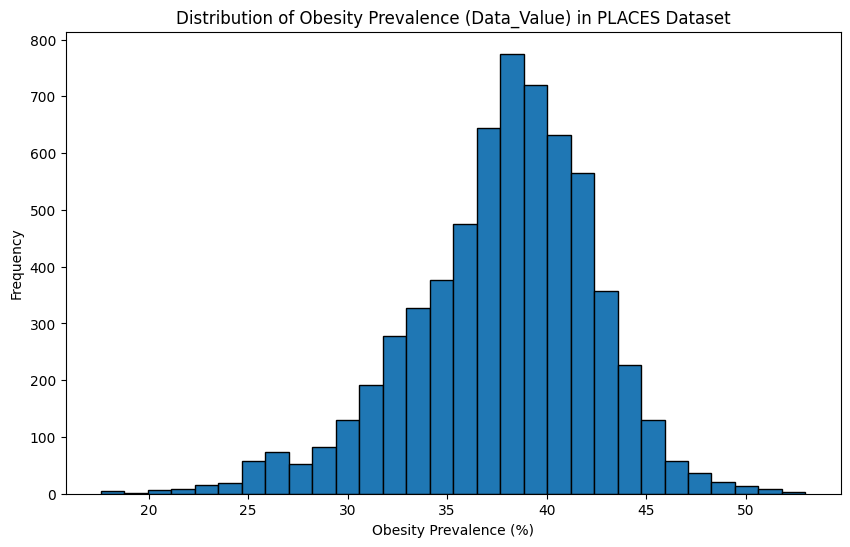

In [ ]:
# Create a histogram for the 'Data_Value' (Obesity Prevalence) column
plt.figure(figsize=(10, 6))
plt.hist(obesity_df['Data_Value'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Obesity Prevalence (Data_Value) in PLACES Dataset')
plt.xlabel('Obesity Prevalence (%)')
plt.ylabel('Frequency')
plt.show()

**Data Joining/Cleaning:**
For the PLACES dataset TotalPopulation column was converted to a numeric data type after removing the comma from the value, and the dataset was filtered on the MeasureID to keep only the statistics on Obesity.

The process of joining the two datasets involved merging them on a custom created LocationID key, which was created by combining state and county codes from the EPA data, to match the LocationID from the PLACES dataset. Then the LocationIDs were grouped together in the EPA dataset to represent the entire county rather than individual blocks.


In [ ]:
def create_location_id(row):
    """Combines STATEFP and COUNTYFP to create a 5-digit LocationID."""
    return f"{row['STATEFP']:02d}{row['COUNTYFP']:03d}"

epa_df['LocationID'] = epa_df.apply(create_location_id, axis=1)

# Display the first few rows with the new LocationID column
display(epa_df[['STATEFP', 'COUNTYFP', 'LocationID']].head())

,STATEFP,COUNTYFP,LocationID
0,48,113,48113
1,48,113,48113
2,48,113,48113
3,48,113,48113
4,48,113,48113


In [ ]:
# Select the specified columns from epa_df
epa_filtered_df = epa_df[['LocationID', 'NatWalkInd', 'CBSA_Name', 'TotPop', 'D2A_Ranked','D2B_Ranked','D3B_Ranked','D4A_Ranked']]

# Display the first few rows of the filtered DataFrame
display(epa_filtered_df.head())

,LocationID,NatWalkInd,CBSA_Name,TotPop,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked
0,48113,14.000000,"Dallas-Fort Worth-Arlington, TX",1202,6,14,15,17
1,48113,10.833333,"Dallas-Fort Worth-Arlington, TX",710,3,10,12,14
2,48113,8.333333,"Dallas-Fort Worth-Arlington, TX",737,1,1,7,17
3,48113,15.666667,"Dallas-Fort Worth-Arlington, TX",904,16,10,17,17
4,48113,10.166667,"Dallas-Fort Worth-Arlington, TX",948,4,7,11,14


In [ ]:
# Group by LocationID and aggregate the specified columns
epa_grouped_df = epa_filtered_df.groupby('LocationID').agg({
    'NatWalkInd': 'mean',
    'D2A_Ranked': 'mean',
    'D2B_Ranked': 'mean',
    'D3B_Ranked': 'mean',
    'D4A_Ranked': 'mean',
    'TotPop': 'sum',
}).reset_index()

# Display the first few rows of the grouped DataFrame
display(epa_grouped_df.head())

,LocationID,NatWalkInd,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,TotPop
0,01001,5.234375,9.156250,9.375000,5.437500,1.0,55200
1,01003,6.450355,12.542553,12.840426,5.659574,1.0,208107
2,01005,5.188406,12.217391,9.521739,3.695652,1.0,25782
3,01007,5.033333,11.266667,10.666667,3.133333,1.0,22527
4,01009,4.666667,9.085714,9.828571,3.542857,1.0,57645


After the EPA dataset was grouped it was joined with the PLACES dataset using an inner join on the LocationID column keeping only the rows with a LocationID in both datasets.

In [ ]:
epa_grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3233 entries, 0 to 3232
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LocationID  3233 non-null   object 
 1   NatWalkInd  3233 non-null   float64
 2   D2A_Ranked  3233 non-null   float64
 3   D2B_Ranked  3233 non-null   float64
 4   D3B_Ranked  3233 non-null   float64
 5   D4A_Ranked  3233 non-null   float64
 6   TotPop      3233 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 176.9+ KB


In [ ]:
# Convert 'LocationID' in obesity_df to string to match epa_grouped_df
obesity_df['LocationID'] = obesity_df['LocationID'].astype(str)

# Merge the two dataframes on 'LocationID'
merged_df = pd.merge(epa_grouped_df, obesity_df, on='LocationID', how='inner')

# Display the first few rows of the merged DataFrame
display(merged_df.head())

/tmp/ipython-input-855974988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obesity_df['LocationID'] = obesity_df['LocationID'].astype(str)


,LocationID,NatWalkInd,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,TotPop,Year,StateAbbr,StateDesc,...,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,10001,8.282407,10.986111,11.069444,6.472222,7.347222,174822,2022,DE,Delaware,...,NaN,33.1,45.0,"186,946","144,450",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.5682629704417 39.0863622587062)
1,10001,8.282407,10.986111,11.069444,6.472222,7.347222,174822,2022,DE,Delaware,...,NaN,33.4,45.3,"186,946","144,450",HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-75.5682629704417 39.0863622587062)
2,10003,11.746830,11.173913,10.236413,11.845109,12.690217,555133,2022,DE,Delaware,...,NaN,32.4,43.7,"575,494","454,447",HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-75.647957543666 39.5816046675309)
3,10003,11.746830,11.173913,10.236413,11.845109,12.690217,555133,2022,DE,Delaware,...,NaN,32.4,43.8,"575,494","454,447",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.647957543666 39.5816046675309)
4,10005,8.187811,11.932836,11.164179,7.791045,5.223881,219540,2022,DE,Delaware,...,NaN,32.6,44.1,"255,956","211,372",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.3899993656017 38.6607348167294)


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5652 entries, 0 to 5651
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LocationID                  5652 non-null   object 
 1   NatWalkInd                  5652 non-null   float64
 2   D2A_Ranked                  5652 non-null   float64
 3   D2B_Ranked                  5652 non-null   float64
 4   D3B_Ranked                  5652 non-null   float64
 5   D4A_Ranked                  5652 non-null   float64
 6   TotPop                      5652 non-null   int64  
 7   Year                        5652 non-null   int64  
 8   StateAbbr                   5652 non-null   object 
 9   StateDesc                   5652 non-null   object 
 10  LocationName                5652 non-null   object 
 11  DataSource                  5652 non-null   object 
 12  Category                    5652 non-null   object 
 13  Measure                     5652 

In [ ]:
# Convert 'TotalPopulation' to numeric by removing commas and converting to int
merged_df['TotalPopulation'] = merged_df['TotalPopulation'].astype(str).str.replace(',', '', regex=False)
merged_df['TotalPopulation'] = pd.to_numeric(merged_df['TotalPopulation'], errors='coerce')

# Display the data types of the TotalPopulation column to confirm the change
display(merged_df['TotalPopulation'].dtype)

dtype('int64')

**Basic Data Characteristics/Visualization:**

In [ ]:
# Rename the specified columns in merged_df
merged_df = merged_df.rename(columns={
    'D2A_Ranked': 'Land_Use_Mix_Rank',
    'D2B_Ranked': 'Employment_Diversity_Rank',
    'D3B_Ranked': 'Street_Connectivity_Rank',
    'D4A_Ranked': 'Transit_Access_Rank'
})

# Display the first few rows with the renamed columns
display(merged_df.head())

,LocationID,NatWalkInd,Land_Use_Mix_Rank,Employment_Diversity_Rank,Street_Connectivity_Rank,Transit_Access_Rank,TotPop,Year,StateAbbr,StateDesc,...,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,10001,8.282407,10.986111,11.069444,6.472222,7.347222,174822,2022,DE,Delaware,...,NaN,33.1,45.0,186946,"144,450",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.5682629704417 39.0863622587062)
1,10001,8.282407,10.986111,11.069444,6.472222,7.347222,174822,2022,DE,Delaware,...,NaN,33.4,45.3,186946,"144,450",HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-75.5682629704417 39.0863622587062)
2,10003,11.746830,11.173913,10.236413,11.845109,12.690217,555133,2022,DE,Delaware,...,NaN,32.4,43.7,575494,"454,447",HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-75.647957543666 39.5816046675309)
3,10003,11.746830,11.173913,10.236413,11.845109,12.690217,555133,2022,DE,Delaware,...,NaN,32.4,43.8,575494,"454,447",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.647957543666 39.5816046675309)
4,10005,8.187811,11.932836,11.164179,7.791045,5.223881,219540,2022,DE,Delaware,...,NaN,32.6,44.1,255956,"211,372",HLTHOUT,OBESITY,CrdPrv,Obesity,POINT (-75.3899993656017 38.6607348167294)


In [ ]:
def count_null_values(df):
    for column in df.columns:
        null_count = df[column].isnull().sum()
        print(f"Column '{column}': {null_count} null values")

count_null_values(merged_df)

Column 'LocationID': 0 null values
Column 'NatWalkInd': 0 null values
Column 'Land_Use_Mix_Rank': 0 null values
Column 'Employment_Diversity_Rank': 0 null values
Column 'Street_Connectivity_Rank': 0 null values
Column 'Transit_Access_Rank': 0 null values
Column 'TotPop': 0 null values
Column 'Year': 0 null values
Column 'StateAbbr': 0 null values
Column 'StateDesc': 0 null values
Column 'LocationName': 0 null values
Column 'DataSource': 0 null values
Column 'Category': 0 null values
Column 'Measure': 0 null values
Column 'Data_Value_Unit': 0 null values
Column 'Data_Value_Type': 0 null values
Column 'Data_Value': 0 null values
Column 'Data_Value_Footnote_Symbol': 5652 null values
Column 'Data_Value_Footnote': 5652 null values
Column 'Low_Confidence_Limit': 0 null values
Column 'High_Confidence_Limit': 0 null values
Column 'TotalPopulation': 0 null values
Column 'TotalPop18plus': 0 null values
Column 'CategoryID': 0 null values
Column 'MeasureId': 0 null values
Column 'DataValueTypeID':

In [ ]:
selected_columns = merged_df[['TotalPopulation','NatWalkInd', 'Land_Use_Mix_Rank', 'Employment_Diversity_Rank', 'Street_Connectivity_Rank', 'Transit_Access_Rank', 'Data_Value']]

display(selected_columns.describe().T)

,count,mean,std,min,25%,50%,75%,max
TotalPopulation,5652.0,95038.701699,256140.881570,51.000000,10695.000000,25899.000000,66695.000000,5.109292e+06
NatWalkInd,5652.0,6.470105,1.929253,2.722222,5.287879,6.077896,7.018519,1.581250e+01
Land_Use_Mix_Rank,5652.0,11.422828,2.003497,4.500000,10.155556,11.266667,12.558824,2.000000e+01
Employment_Diversity_Rank,5652.0,10.967697,2.254999,1.000000,9.532258,10.720360,12.142857,2.000000e+01
Street_Connectivity_Rank,5652.0,6.039962,3.115578,1.000000,3.633333,5.515207,7.958333,1.736842e+01
Transit_Access_Rank,5652.0,2.175091,3.228850,1.000000,1.000000,1.000000,1.000000,1.885105e+01
Data_Value,5652.0,38.094639,4.261971,20.900000,35.600000,38.400000,41.000000,5.300000e+01


## EDA and Feature Engineering

### Summary of EDA

The EDA involved exploring the distributions of the walkability components (`D2A_Ranked`, `D2B_Ranked`, `D3B_Ranked`, `D4A_Ranked`, and `NatWalkInd`) and obesity prevalence (`Data_Value`) through histograms. I also visualized the relationship between each walkability component and obesity prevalence using scatter plots, including adding regression lines to understand the linear trends. A correlation heatmap was generated to assess the linear relationships between all selected variables.

Additionally, I examined the relationship between walkability and obesity prevalence while considering population density, categorizing counties into 'High Population' and 'Low Population' based on the median `TotalPopulation`. Scatter plots and lmplots were used to visualize this relationship for each population category. Finally, I compared the average obesity prevalence and average National Walkability Index across different states using bar plots and a scatter plot with state labels to identify any geographical patterns or outliers.

### Feature Engineering

The primary feature engineering step involved creating a `LocationID` in the `epa_df` by combining the `STATEFP` and `COUNTYFP` columns. This was done to facilitate merging the `epa_df` and `places_df` datasets. The `TotalPopulation` column in the `places_df` was also cleaned by removing commas and converting it to a numeric data type.

After merging the datasets and grouping the EPA data by the newly created `LocationID`, we calculated the mean of the walkability component ranks (`D2A_Ranked`, `D2B_Ranked`, `D3B_Ranked`, `D4A_Ranked`) and the `NatWalkInd` for each county. The `TotPop` was summed for each county.

I also renamed the EPA walkability component columns to be more descriptive:
- `D2A_Ranked` to `Land_Use_Mix_Rank`
- `D2B_Ranked` to `Employment_Diversity_Rank`
- `D3B_Ranked` to `Street_Connectivity_Rank`
- `D4A_Ranked` to `Transit_Access_Rank`

Finally, I created a new categorical feature `Population_Category` in the merged DataFrame based on whether a county's `TotalPopulation` was above or below the median population of all counties in the merged dataset.

### What I Learned

*   **Walkability and Obesity:** The scatter plots and regression lines generally showed a negative relationship between walkability metrics and obesity prevalence, suggesting that areas with higher walkability tend to have lower obesity rates. However, the strength of this relationship varied among the different walkability components.
*   **Population Density Influence:** The analysis of walkability and obesity by population category suggested that the relationship between walkability and obesity might be slightly stronger in high-population areas.
*   **Correlation Insights:** The correlation heatmap provided quantitative insights into the linear relationships. `NatWalkInd` showed the strongest negative correlation with `Data_Value` (obesity prevalence) among the walkability metrics. Some of the walkability component ranks also showed moderate correlations with `Data_Value`. The walkability component ranks themselves were also correlated with each other, particularly `Street_Connectivity_Rank` and `Transit_Access_Rank` with `NatWalkInd`.
*   **Geographical Variation:** The bar plots and the state-level scatter plot highlighted significant variations in both average obesity prevalence and average walkability across states, indicating that geographical factors play a role. Some states with higher average walkability appeared to have lower average obesity prevalence, aligning with the overall trend, but there were exceptions.
*   **Data Readiness:** The data cleaning and joining steps were successful, and the engineered features were ready for use in the regression model as confirmed by the null value check. The ranked nature of the walkability components meant that explicit normalization or scaling of these features wasn't strictly necessary before building the linear regression model.

# Research Question

Can a machine learning regression model accurately predict the obesity percentage using the national walkability score and its underlying component variables as predictors?

*   **Type of Machine Learning Question:** This is a **supervised learning** problem, specifically a **regression** task, as the goal is to predict a continuous numerical value (obesity prevalence).
*   **Predictor Variables (Independent Variables):** The predictor variables are the walkability components from the EPA dataset, which include:
    *   National Walkability Index (`NatWalkInd`)
    *   Land Use Mix Rank (`Land_Use_Mix_Rank`)
    *   Employment Diversity Rank (`Employment_Diversity_Rank`)
    *   Street Connectivity Rank (`Street_Connectivity_Rank`)
    *   Transit Access Rank (`Transit_Access_Rank`)
*   **Response Variable (Dependent Variable):** The response variable is the obesity prevalence (`Data_Value`) from the PLACES dataset.

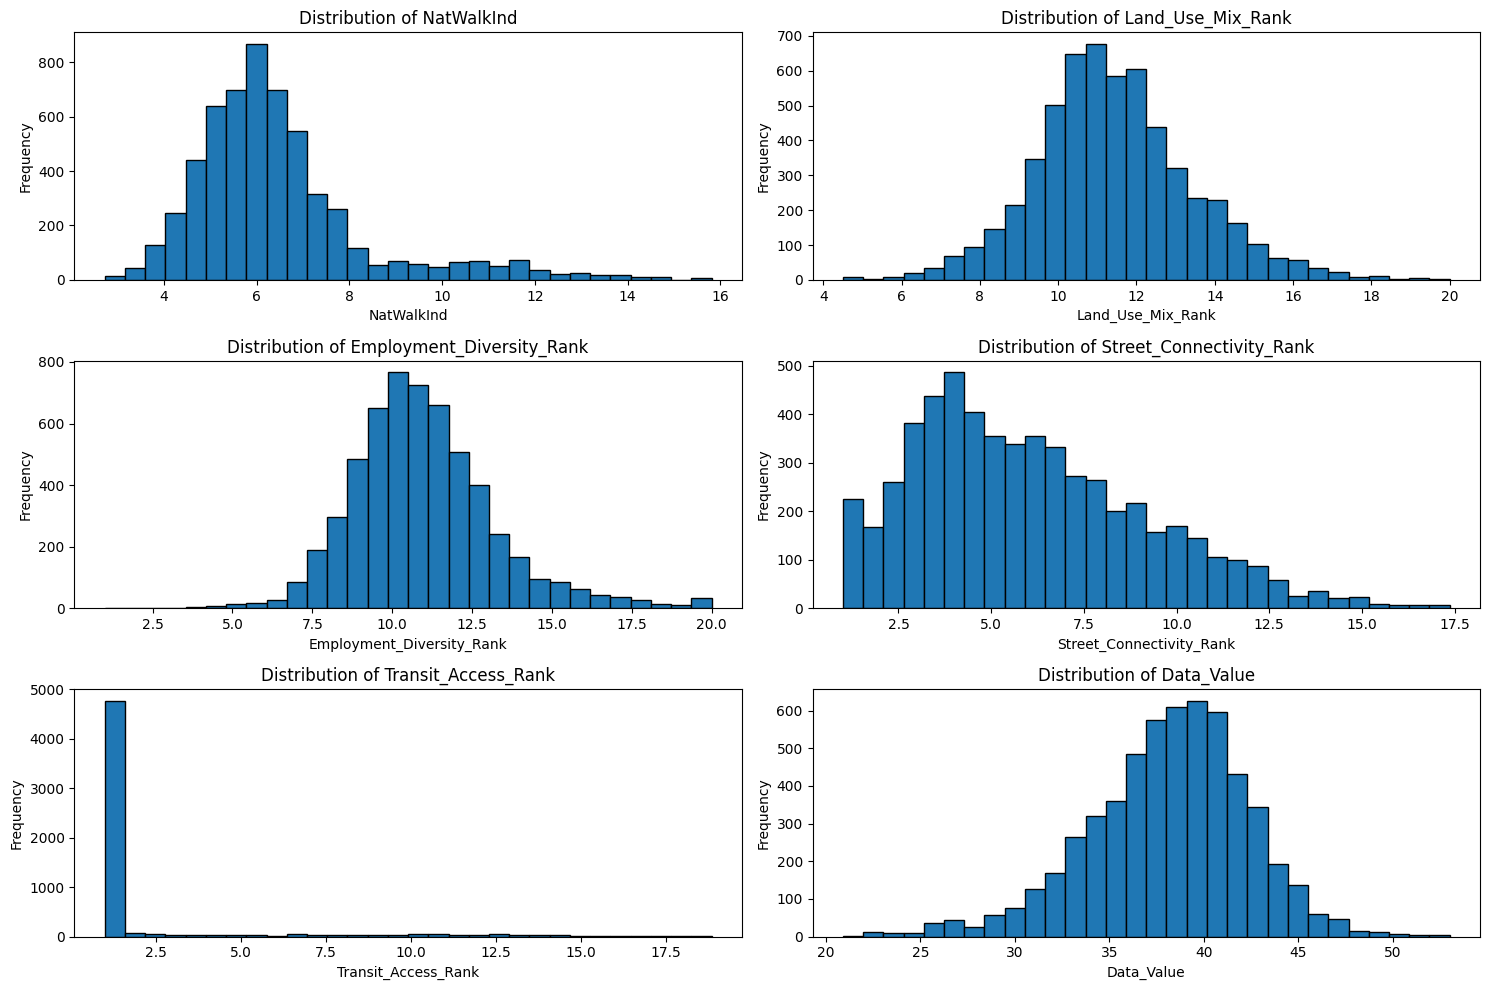

In [ ]:
import matplotlib.pyplot as plt

# Define the columns to plot
cols_to_plot = ['NatWalkInd', 'Land_Use_Mix_Rank', 'Employment_Diversity_Rank', 'Street_Connectivity_Rank', 'Transit_Access_Rank', 'Data_Value']

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(merged_df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

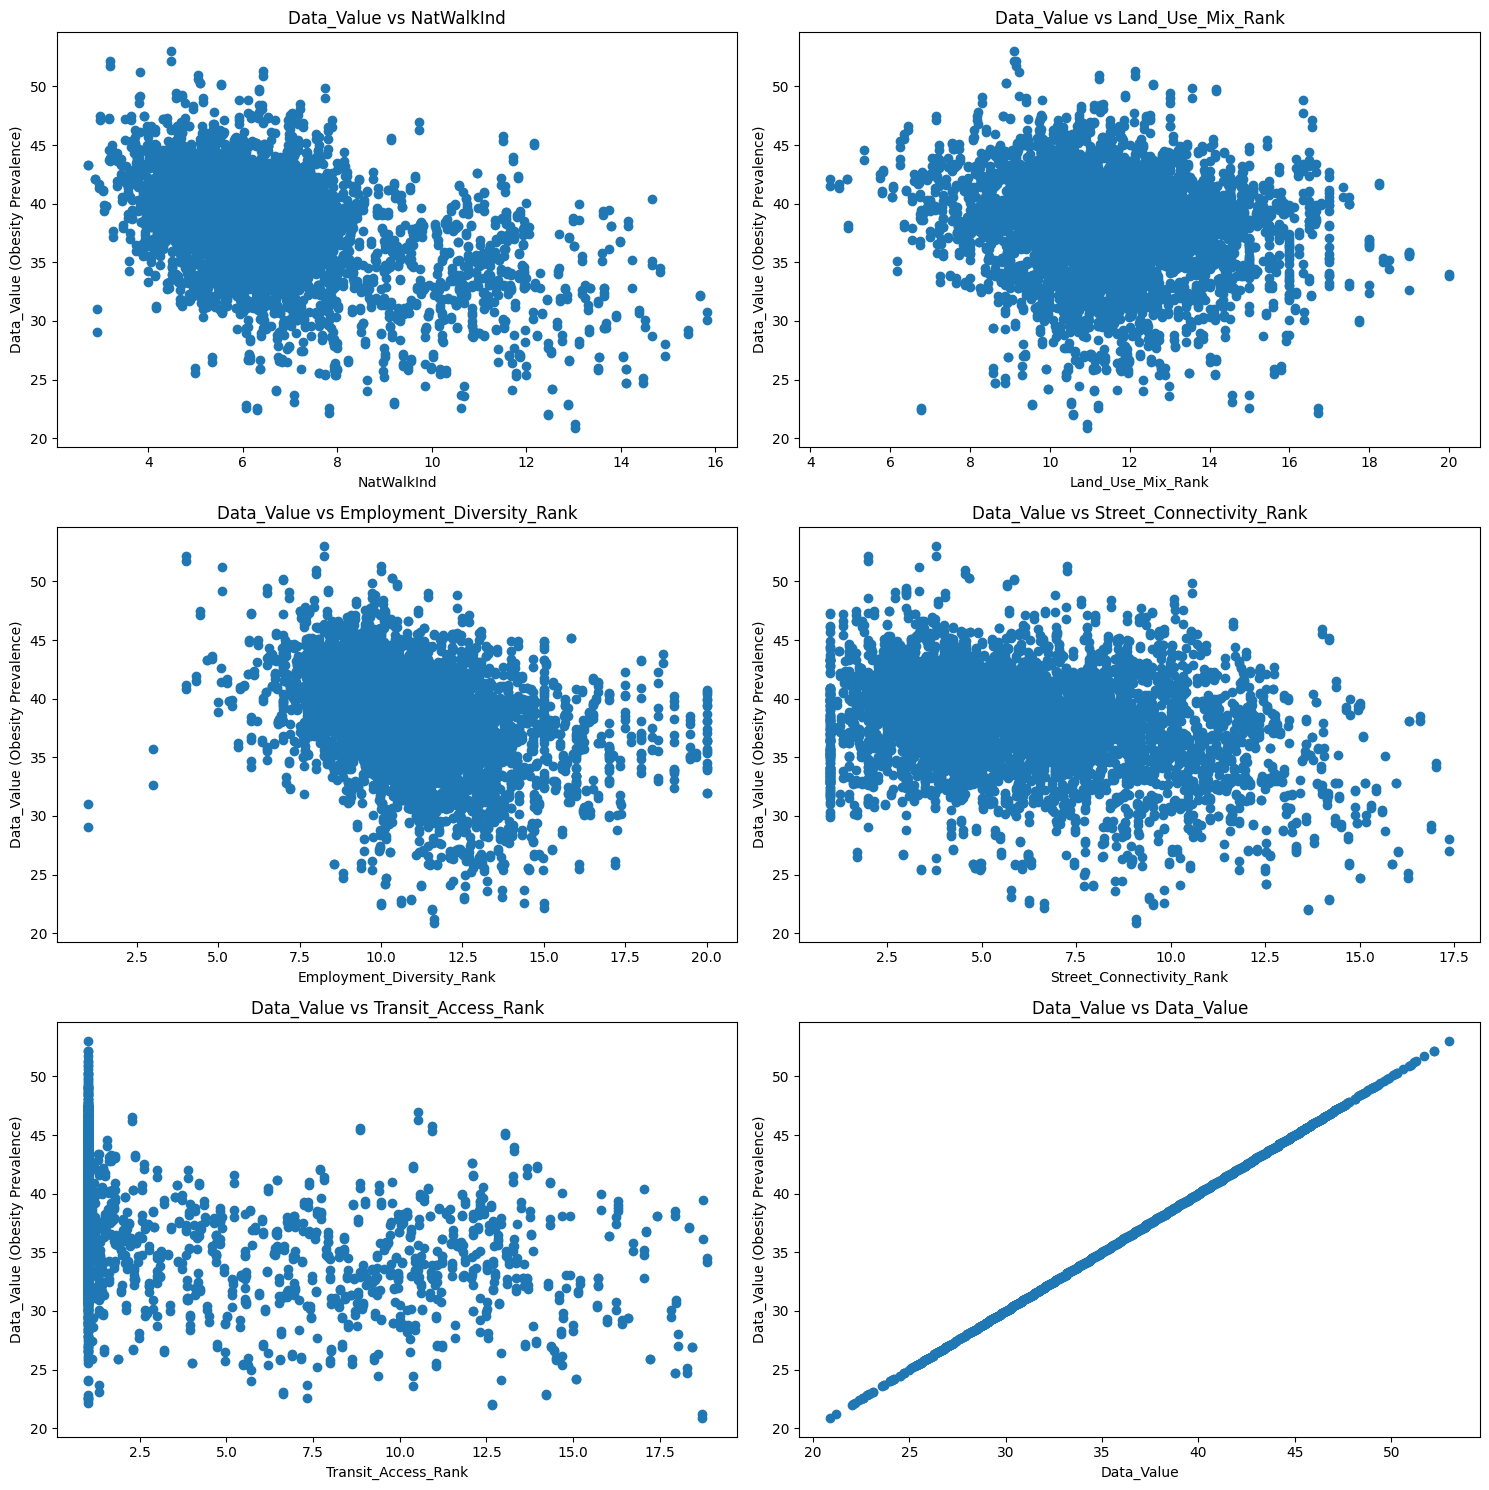

In [ ]:
n_cols = 2
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

# Plot scatter plot for each column against Data_Value
for i, col in enumerate(cols_to_plot):
    axes[i].scatter(merged_df[col], merged_df['Data_Value'])
    axes[i].set_title(f'Data_Value vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Data_Value (Obesity Prevalence)')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

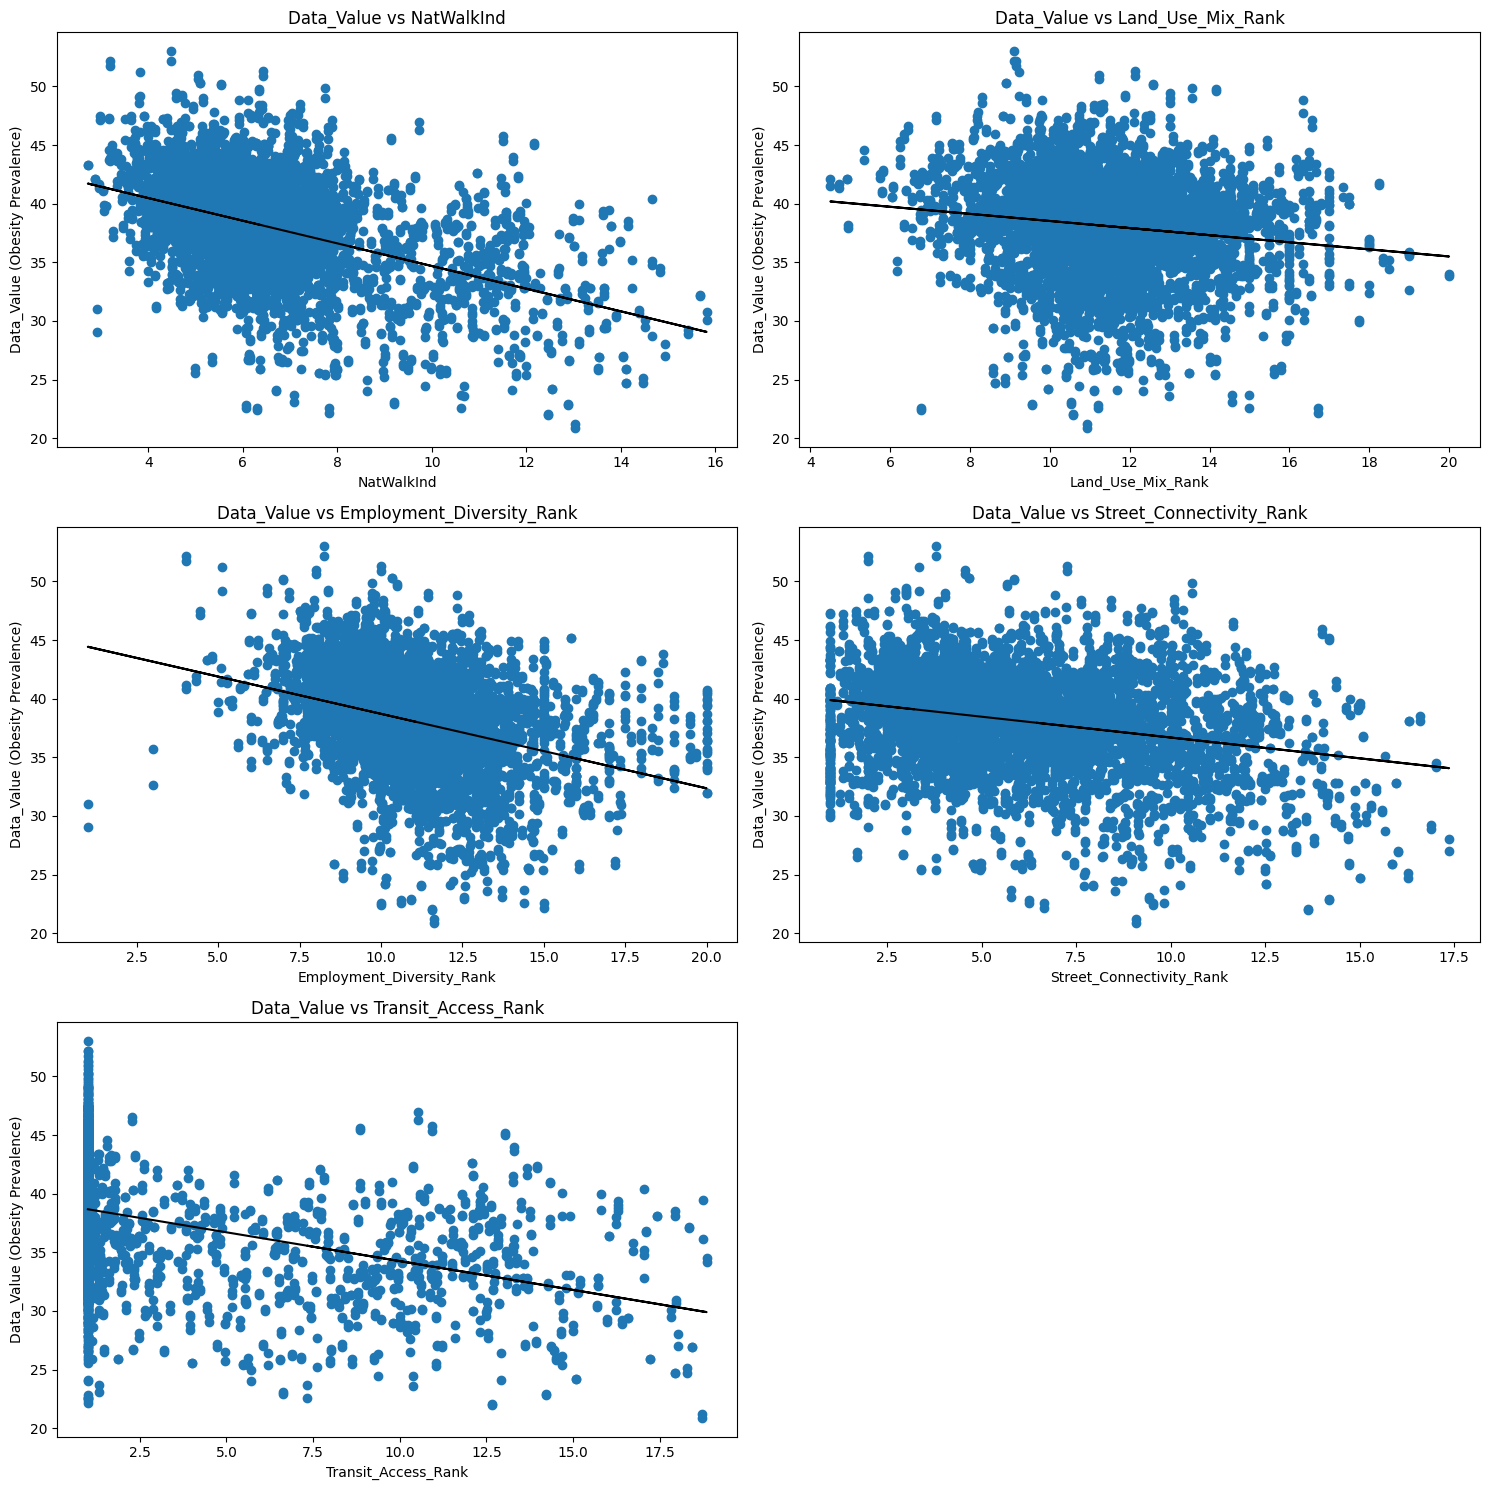

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cols_to_plot = ['NatWalkInd', 'Land_Use_Mix_Rank', 'Employment_Diversity_Rank', 'Street_Connectivity_Rank', 'Transit_Access_Rank']

n_cols = 2
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].scatter(merged_df[col], merged_df['Data_Value'], label='Data Points')
    valid_data = merged_df[[col, 'Data_Value']].dropna()
    if not valid_data.empty:
        x = np.asarray(valid_data[col]).flatten()
        y = np.asarray(valid_data['Data_Value']).flatten()
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m*x + b, color='black', label=f'Regression Line (y={m:.2f}x + {b:.2f})')

    axes[i].set_title(f'Data_Value vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Data_Value (Obesity Prevalence)')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

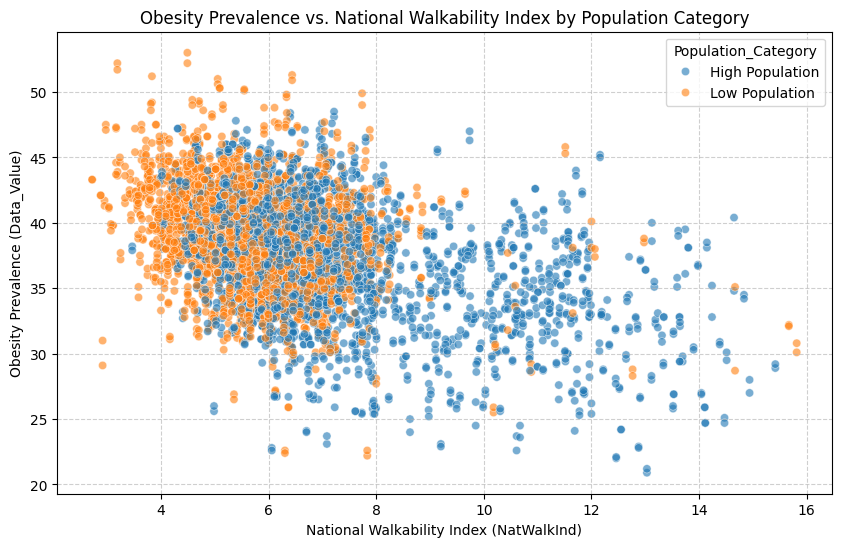

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define a threshold for high vs. low population (using the median as an example)
population_threshold = merged_df['TotalPopulation'].median()

# Categorize areas based on population
merged_df['Population_Category'] = np.where(merged_df['TotalPopulation'] >= population_threshold, 'High Population', 'Low Population')

# Create a scatter plot with color distinguishing population categories
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='NatWalkInd', y='Data_Value', hue='Population_Category', alpha=0.6)

plt.title('Obesity Prevalence vs. National Walkability Index by Population Category')
plt.xlabel('National Walkability Index (NatWalkInd)')
plt.ylabel('Obesity Prevalence (Data_Value)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

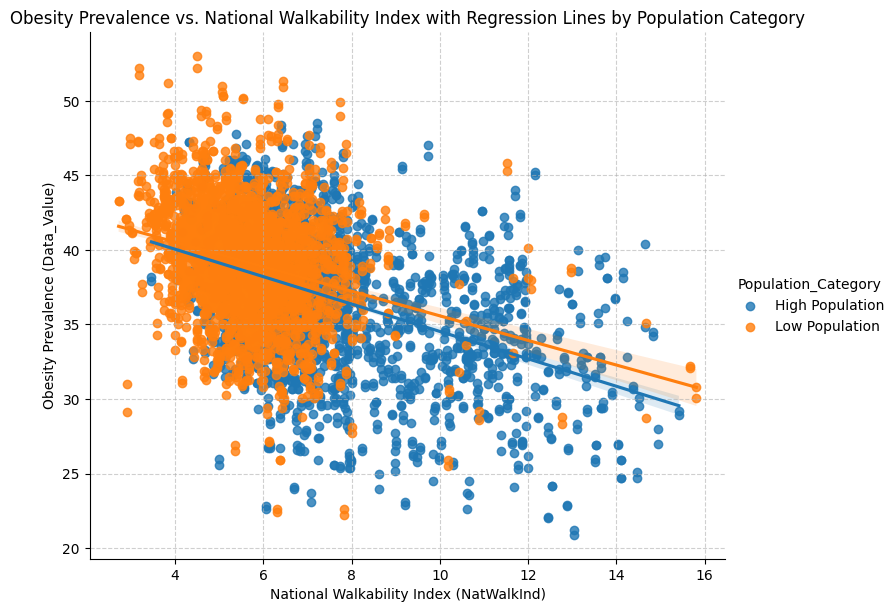

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create an lmplot to show the relationship between NatWalkInd and Data_Value with regression lines for each population category
sns.lmplot(data=merged_df, x='NatWalkInd', y='Data_Value', hue='Population_Category', height=6, aspect=1.2)

plt.title('Obesity Prevalence vs. National Walkability Index with Regression Lines by Population Category')
plt.xlabel('National Walkability Index (NatWalkInd)')
plt.ylabel('Obesity Prevalence (Data_Value)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatter plot shows the relationship between the National Walkability Index and Obesity Prevalence, with points colored by population density. The regression lines suggest a similar negative trend between walkability and obesity prevalence in both high and low population areas, though the relationship appears slightly stronger in high population areas. This implies that while walkability is generally associated with lower obesity rates, population density might influence the strength of this association.

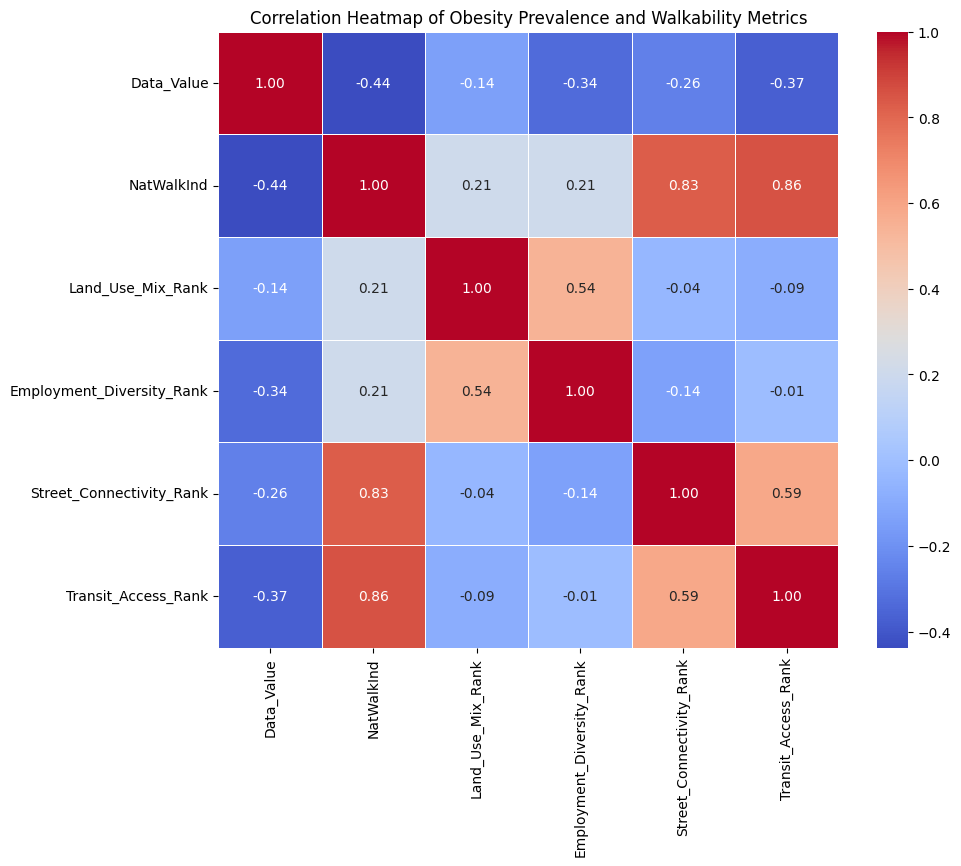

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for correlation analysis
correlation_columns = ['Data_Value', 'NatWalkInd', 'Land_Use_Mix_Rank', 'Employment_Diversity_Rank', 'Street_Connectivity_Rank', 'Transit_Access_Rank']
correlation_df = merged_df[correlation_columns]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Obesity Prevalence and Walkability Metrics')
plt.show()

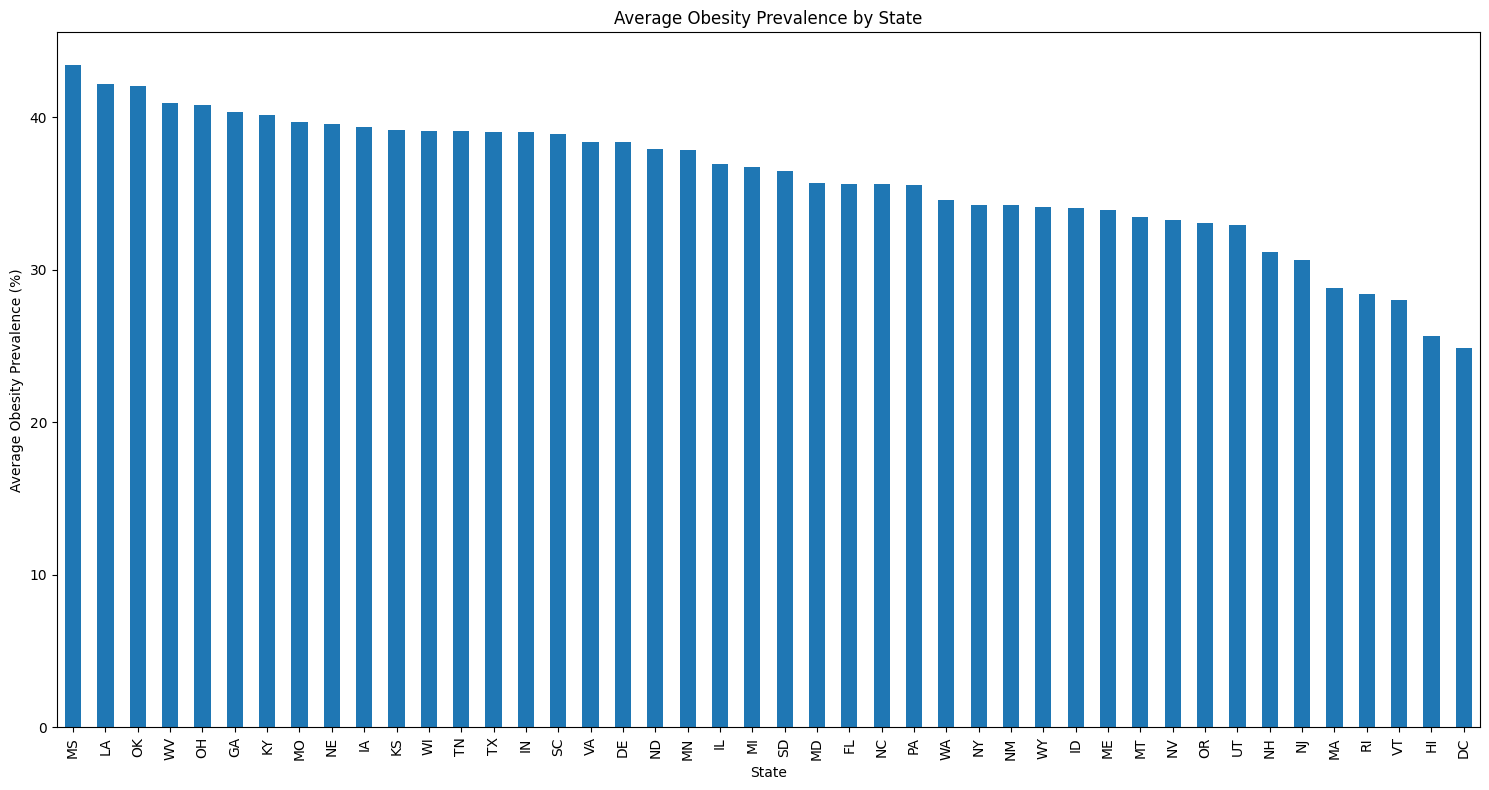

In [ ]:
# Calculate the average obesity prevalence per state
average_obesity_per_state = merged_df.groupby('StateAbbr')['Data_Value'].mean().sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(15, 8))
average_obesity_per_state.plot(kind='bar')
plt.title('Average Obesity Prevalence by State')
plt.xlabel('State')
plt.ylabel('Average Obesity Prevalence (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

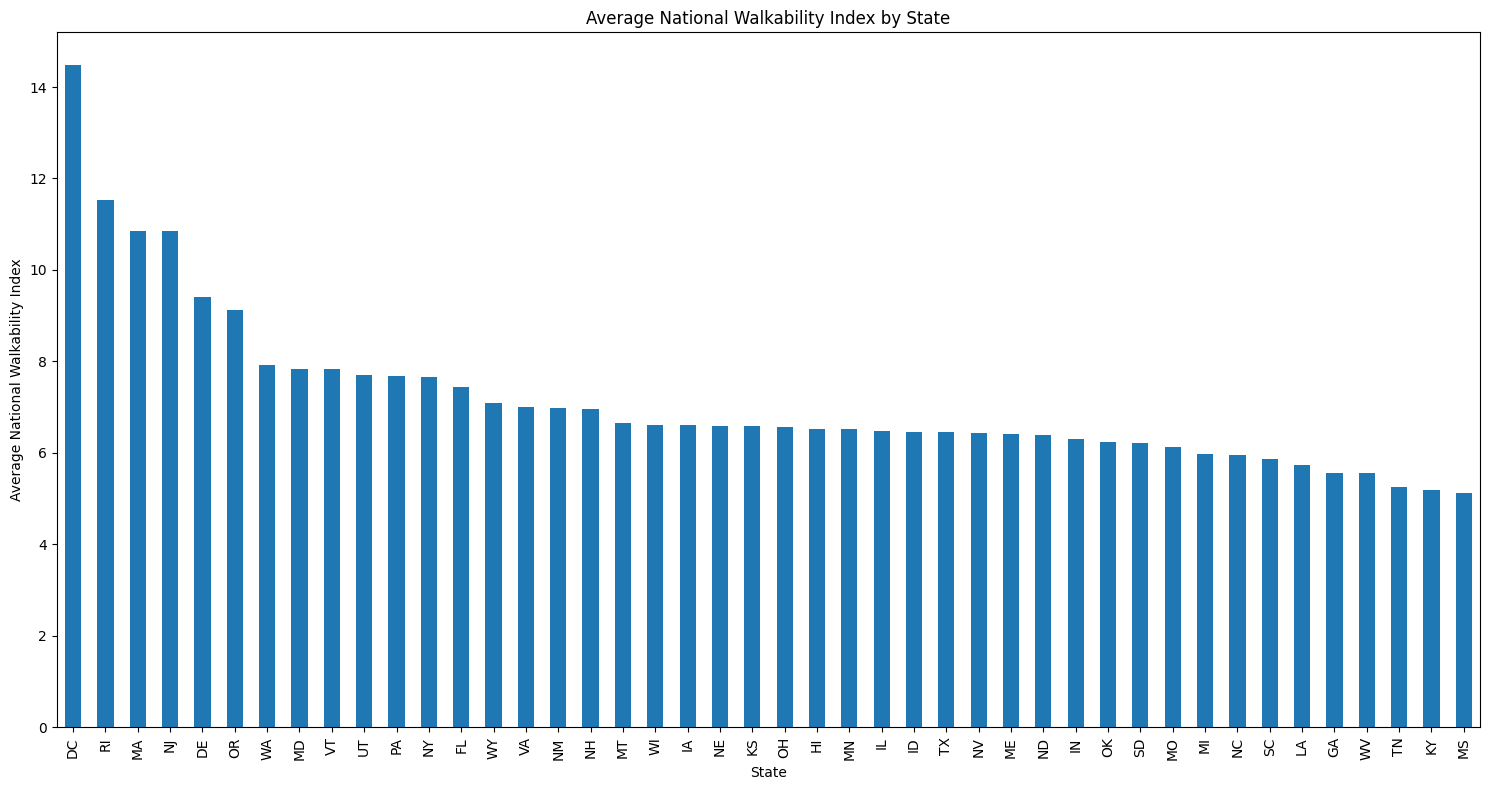

In [ ]:
import matplotlib.pyplot as plt

# Calculate the average NatWalkInd per state
average_natwalkind_per_state = merged_df.groupby('StateAbbr')['NatWalkInd'].mean().sort_values(ascending=False)

# Create a bar plot for average NatWalkInd per state
plt.figure(figsize=(15, 8))
average_natwalkind_per_state.plot(kind='bar')
plt.title('Average National Walkability Index by State')
plt.xlabel('State')
plt.ylabel('Average National Walkability Index')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3676860372.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(state, (state_comparison_df['Average_NatWalkInd'][i], state_comparison_df['Average_Obesity_Prevalence'][i]), fontsize=9)


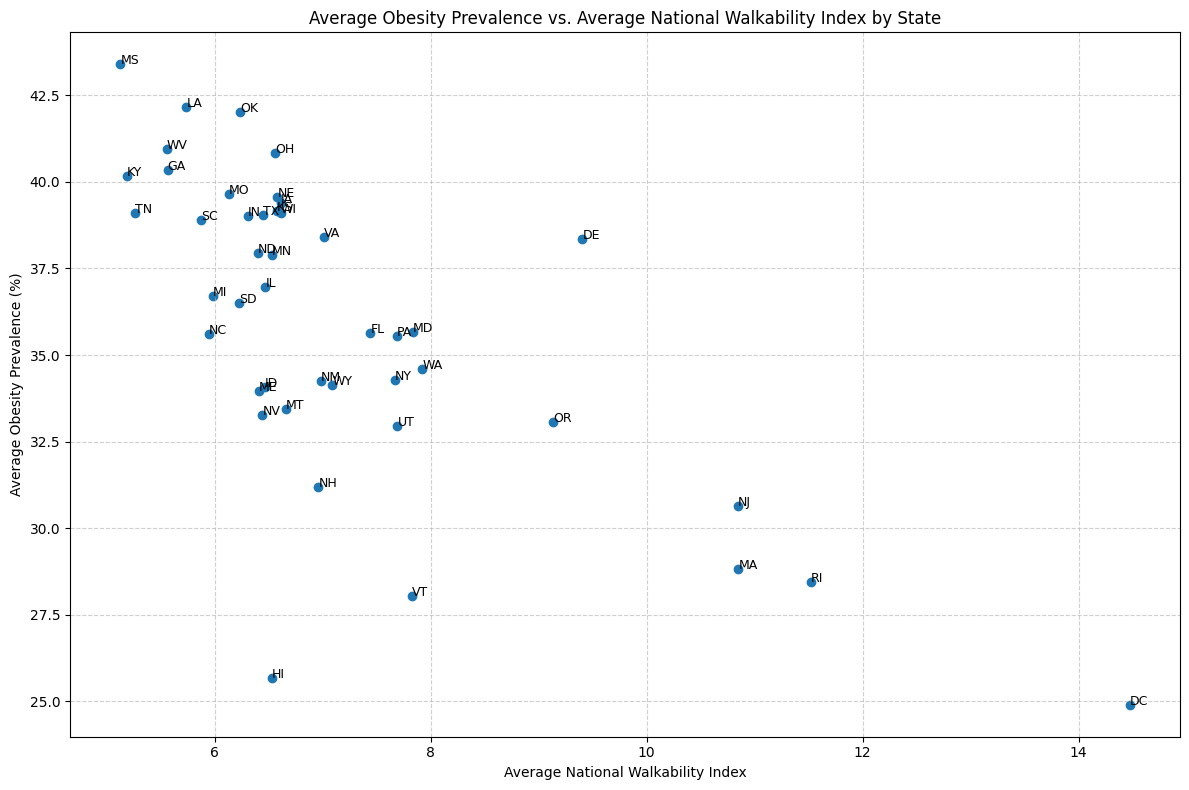

In [ ]:
# Calculate the average NatWalkInd per state
average_natwalkind_per_state = merged_df.groupby('StateAbbr')['NatWalkInd'].mean().sort_values(ascending=False)

# Merge the two average dataframes
state_comparison_df = pd.merge(average_obesity_per_state, average_natwalkind_per_state, left_index=True, right_index=True)
state_comparison_df.columns = ['Average_Obesity_Prevalence', 'Average_NatWalkInd']

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(state_comparison_df['Average_NatWalkInd'], state_comparison_df['Average_Obesity_Prevalence'])
plt.title('Average Obesity Prevalence vs. Average National Walkability Index by State')
plt.xlabel('Average National Walkability Index')
plt.ylabel('Average Obesity Prevalence (%)')
plt.grid(True, linestyle='--', alpha=0.6)

# Add labels for each state
for i, state in enumerate(state_comparison_df.index):
    plt.annotate(state, (state_comparison_df['Average_NatWalkInd'][i], state_comparison_df['Average_Obesity_Prevalence'][i]), fontsize=9)

plt.tight_layout()
plt.show()

# Exploratory Data Analysis

## Performance Evaluation and Featurization Improvement

### Performance Evaluation

The model's performance will be evaluated using several metrics to provide a comprehensive understanding of its predictive capabilities:

*   **R-squared (R²):** This metric will be used to assess the proportion of the variance in the obesity prevalence that is predictable from the walkability features. A higher R² indicates a better fit of the model to the data.
*   **Root Mean Squared Error (RMSE):** RMSE will measure the average magnitude of the errors between the predicted and actual obesity prevalence values. A lower RMSE indicates better predictive accuracy.
*   **Cross-Validation:** K-fold cross-validation will be employed to obtain a more robust estimate of the model's performance and to assess its generalization ability on unseen data. This helps to mitigate the risk of overfitting to a single train-test split.

### Featurization Improvement

The feature engineering process involved several key steps to prepare the data for modeling. First, a LocationID was created in the EPA dataset by combining state and county codes to enable a successful merge with the PLACES dataset. The TotalPopulation column was cleaned by removing non numeric characters and converting it to a numeric format.

Following the merge, the EPA data was grouped by LocationID. The walkability component ranks (D2A_Ranked, D2B_Ranked, D3B_Ranked, D4A_Ranked) and the National Walkability Index (NatWalkInd) were aggregated using the mean for each county, while the total population was summed. To improve readability, the walkability component columns were renamed to Land_Use_Mix_Rank, Employment_Diversity_Rank, Street_Connectivity_Rank, and Transit_Access_Rank.

Finally, a categorical feature named Population_Category was created. This feature classifies counties as High Population or Low Population based on whether their population is above or below the median population of the dataset, allowing for analysis of density related patterns.

### Data Exploration and Analysis Reflection

To comprehensively understand the data, I utilized histograms to inspect the distributions of walkability indices and obesity prevalence, and employed scatter plots with regression lines to visualize the potential negative correlations between them. I further investigated these relationships using a correlation heatmap to identify multicollinearity and scatter plots categorized by population density to discern if urban density influenced the trends. My statistical approach initially relied on a baseline Multiple Linear Regression model validated through 5-fold cross validation, but the resulting low predictive power ($R^2 \approx 0.26$) necessitated a major change in strategy. I pivoted to a Gradient Boosting Regressor, justifying this decision by the substantial improvement in model fit ($R^2 \approx 0.78$) and reduced error (RMSE $\approx 1.99$). This shift allowed me to conclude that the influence of the built environment specifically Employment Diversity and Transit Access on obesity is strong but non linear, a complexity that simple linear modeling could not capture.

# Preliminary Results

## Performance Evaluation and Results

For this regression problem, the following performance measures were used:

*   **R-squared (R²):** This metric was chosen to indicate the proportion of the variance in obesity prevalence that is predictable from the walkability features. It provides a measure of how well the model fits the observed data. A higher R² is desired, indicating a better fit.
*   **Root Mean Squared Error (RMSE):** RMSE was used to measure the average magnitude of the errors between the predicted and actual obesity prevalence values. It is a good measure of the model's predictive accuracy, and a lower RMSE indicates better performance.
*   **Cross-Validation (5-fold):** 5-fold cross-validation was implemented to obtain a more robust estimate of the model's performance and assess its generalization ability on unseen data, mitigating the risk of overfitting to a single train-test split. The mean and standard deviation of the RMSE across the folds were calculated.

Based on the multiple linear regression model trained on the walkability components to predict obesity prevalence:

*   **R-squared (R²) Score on the test set:** 0.2605
*   **Root Mean Squared Error (RMSE) on the test set:** 3.6513
*   **Mean RMSE from 5-fold cross-validation:** 3.6807
*   **Standard deviation of RMSE from 5-fold cross-validation:** 0.2886

These results suggest that the linear regression model explains approximately 26.05% of the variance in obesity prevalence. The RMSE values indicate that, on average, the model's predictions are off by about 3.65 to 3.68 percentage points. The cross-validation results show relatively consistent performance across different subsets of the data.

### Tuning and Hypothesis Tests

No specific hyperparameter tuning was performed on this initial linear regression model.

No formal hypothesis tests were conducted as part of this preliminary analysis. The focus was on building a predictive model and evaluating its initial performance.


In [ ]:
features = ['NatWalkInd', 'Land_Use_Mix_Rank', 'Employment_Diversity_Rank', 'Street_Connectivity_Rank', 'Transit_Access_Rank']
target = 'Data_Value'

X = merged_df[features]
y = merged_df[target]

display(X.head())
display(y.head())

,NatWalkInd,Land_Use_Mix_Rank,Employment_Diversity_Rank,Street_Connectivity_Rank,Transit_Access_Rank
0,8.282407,10.986111,11.069444,6.472222,7.347222
1,8.282407,10.986111,11.069444,6.472222,7.347222
2,11.746830,11.173913,10.236413,11.845109,12.690217
3,11.746830,11.173913,10.236413,11.845109,12.690217
4,8.187811,11.932836,11.164179,7.791045,5.223881


,Data_Value
0,38.9
1,39.3
2,37.6
3,37.7
4,38.0


In [ ]:
print("Missing values in features (X):")
print(X.isnull().sum())

print("\nMissing values in target (y):")
print(y.isnull().sum())

Missing values in features (X):
NatWalkInd                   0
Land_Use_Mix_Rank            0
Employment_Diversity_Rank    0
Street_Connectivity_Rank     0
Transit_Access_Rank          0
dtype: int64

Missing values in target (y):
0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4521, 5)
Shape of X_test: (1131, 5)
Shape of y_train: (4521,)
Shape of y_test: (1131,)


In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate a LinearRegression object
model = LinearRegression()

# Fit the linear regression model to the training data
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the testing features
y_pred = model.predict(X_test)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate the Root Mean Squared Error (RMSE) by taking the square root of MSE
rmse = np.sqrt(mse)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)

# Print the calculated metrics
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 3.6513
R-squared (R2) Score: 0.2605


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-fold cross-validation with negative mean squared error scoring
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

# Convert negative MSE scores to positive MSE
mse_scores = -cv_scores

# Calculate the RMSE for each fold and then find the mean and standard deviation
rmse_scores = np.sqrt(mse_scores)
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

# Print the mean and standard deviation of the RMSE from cross-validation
print(f"Mean RMSE from 5-fold cross-validation: {mean_rmse:.4f}")
print(f"Standard deviation of RMSE from 5-fold cross-validation: {std_rmse:.4f}")

Mean RMSE from 5-fold cross-validation: 3.6807
Standard deviation of RMSE from 5-fold cross-validation: 0.2886


## Model Revision

### Scope Refinement and Model Selection
I focused on analyzing data at the **county level**. The EPA data, originally at the census tract level, was aggregated to match the county level health outcomes provided by the CDC PLACES dataset. This decision streamlined the data processing and ensured a consistent unit of analysis for correlating built environment features with obesity rates.

### Final Model Details
My initial linear regression model yielded poor predictive power ($R^2 \approx 0.26$), suggesting that the relationship between walkability and obesity is not strictly linear. I revised the approach to use a **Gradient Boosting Regressor**. This method builds decision trees sequentially, where each new tree corrects the errors of the previous ones, allowing the model to capture complex, non linear interactions between features like transit access and land use mix.

### Initial Results
The revision proved highly effective. The Gradient Boosting model (configured with 300 estimators, a learning rate of 0.2, and a max depth of 5) achieved:
*   **R-squared ($R^2$):** $\approx 0.78$ (up from 0.26), indicating it explains 78% of the variance in obesity prevalence.
*   **RMSE:** $\approx 1.99$ (down from 3.65), significantly reducing the average prediction error.

These results confirm that while walkability is a strong predictor of obesity, the relationship is best modeled using non-linear techniques.

#Full Analysis
The comparison between the Linear Regression model and the Gradient Boosting Regressor reveals a substantial improvement in predictive performance with the latter:

*   **RMSE Improvement:** The Root Mean Squared Error decreased from approximately **3.65** (Linear Regression) to **1.99** (Gradient Boosting). This indicates that the Gradient Boosting model's predictions are, on average, much closer to the actual obesity prevalence values.
*   **R-squared Improvement:** The R-squared score increased dramatically from **0.26** to **0.78**. While the linear model could only explain about 26% of the variance in obesity prevalence, the Gradient Boosting model captures nearly 78% of the variance, demonstrating a much stronger fit to the data.
*   **Feature Importance:** The feature importance analysis for the Gradient Boosting model identifies **Employment_Diversity_Rank** and **Transit_Access_Rank** as the most influential predictors, followed by **NatWalkInd** and **Land_Use_Mix_Rank**. This insight suggests that specific components of walkability have non-linear or interactive effects that the linear model failed to capture effectively.

Overall, the Gradient Boosting Regressor significantly outperforms the baseline Linear Regression model, validating the use of a more complex, non-linear model for this specific problem.

In [ ]:
# Instantiate a new LinearRegression model
lr_model = LinearRegression()

# Fit the model to X_train and y_train
lr_model.fit(X_train, y_train)

# Generate predictions on X_test
y_pred_lr = lr_model.predict(X_test)

# Calculate the RMSE and R-squared score
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Print the baseline performance
print(f"Linear Regression - Test RMSE: {rmse_lr:.4f}")
print(f"Linear Regression - Test R2 Score: {r2_lr:.4f}")

Linear Regression - Test RMSE: 3.6513
Linear Regression - Test R2 Score: 0.2605


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Instantiate the GradientBoostingRegressor
gb_reg = GradientBoostingRegressor(random_state=42)

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=gb_reg, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Calculate the best RMSE
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Best Cross-Validation RMSE: {best_rmse:.4f}")

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best Cross-Validation RMSE: 2.6802


In [ ]:
# Instantiate the GradientBoostingRegressor with the best hyperparameters
best_gb_reg = GradientBoostingRegressor(n_estimators=300, learning_rate=0.2, max_depth=5, random_state=42)

# Fit the model to the training data
best_gb_reg.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_gb = best_gb_reg.predict(X_test)

# Calculate RMSE and R-squared
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

# Print the evaluation metrics
print(f"Gradient Boosting Regressor - Test RMSE: {rmse_gb:.4f}")
print(f"Gradient Boosting Regressor - Test R2 Score: {r2_gb:.4f}")

Gradient Boosting Regressor - Test RMSE: 1.9949
Gradient Boosting Regressor - Test R2 Score: 0.7792


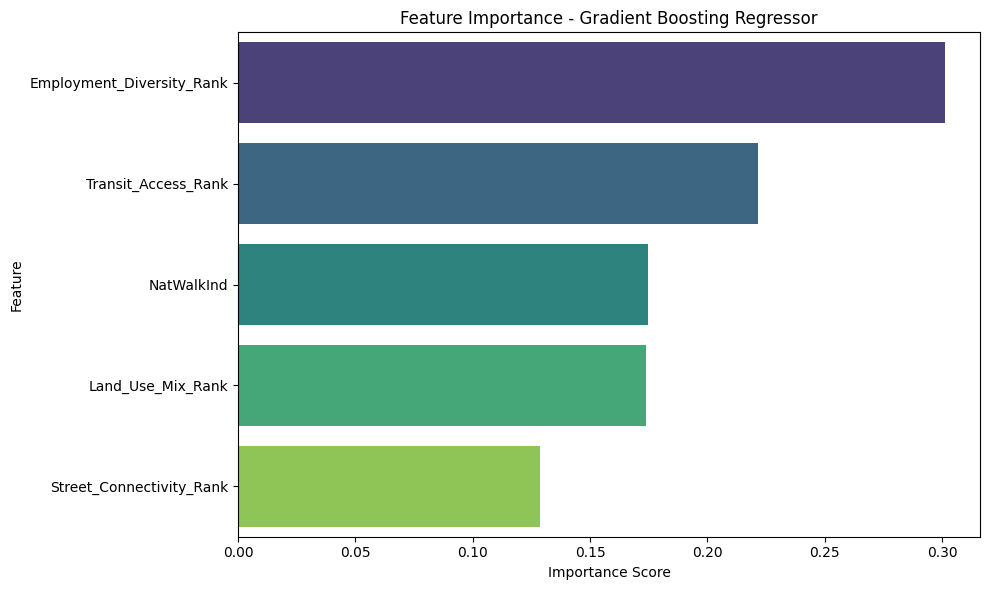

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importances = best_gb_reg.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Gradient Boosting Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

,Model,RMSE,R-squared
0,Linear Regression,3.651282,0.260473
1,Gradient Boosting,1.994941,0.779238


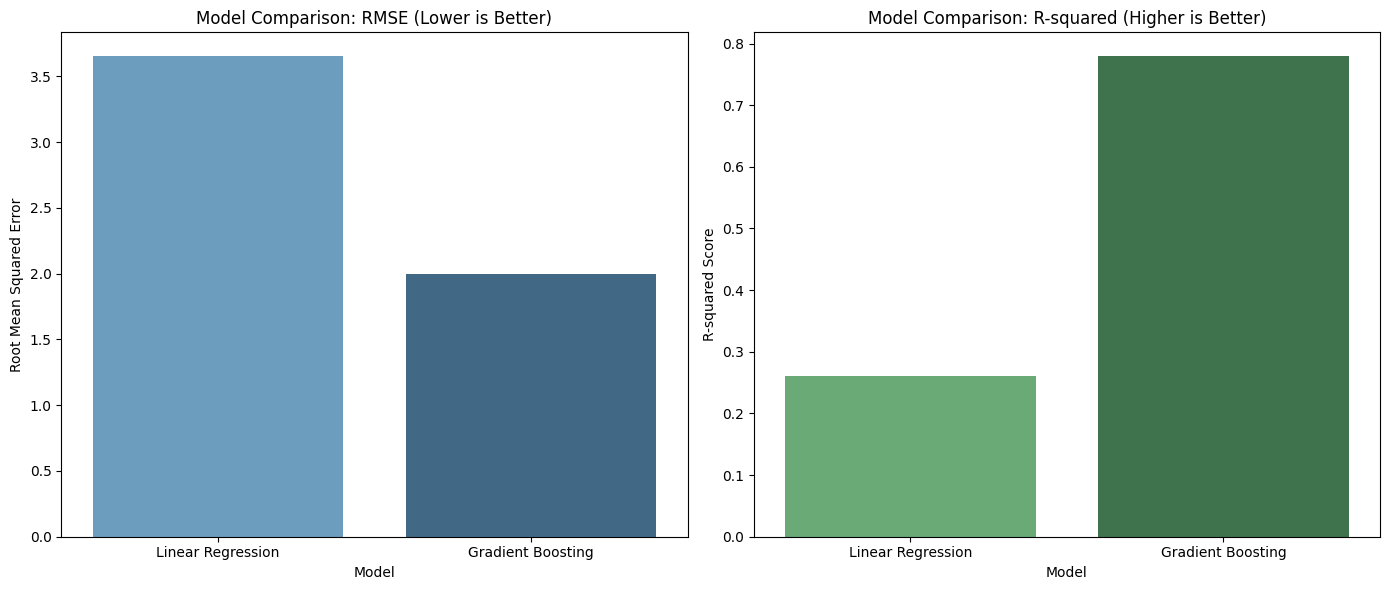

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame to compare performance metrics
comparison_data = {
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_gb],
    'R-squared': [r2_lr, r2_gb]
}
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison DataFrame
display(comparison_df)

# Create subplots for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for RMSE
sns.barplot(x='Model', y='RMSE', data=comparison_df, ax=axes[0], hue='Model', palette='Blues_d', legend=False)
axes[0].set_title('Model Comparison: RMSE (Lower is Better)')
axes[0].set_ylabel('Root Mean Squared Error')

# Bar chart for R-squared
sns.barplot(x='Model', y='R-squared', data=comparison_df, ax=axes[1], hue='Model', palette='Greens_d', legend=False)
axes[1].set_title('Model Comparison: R-squared (Higher is Better)')
axes[1].set_ylabel('R-squared Score')

plt.tight_layout()
plt.show()